# Trabalho Prático – Estrutura de Dados II (DCA3702)



##  Etapa 1 – Construção do grafo com OSMnx



In [6]:
!pip install osmnx seaborn

import os

import osmnx as ox
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Reshimming asdf python...


In [7]:
# Load the urban drive network for the chosen region using OSMnx.
# Each node is a street intersection; each edge is a road segment.
os.makedirs("outputs", exist_ok=True)

place = "Jucurutu, Rio Grande do Norte, Brazil"

G = ox.graph_from_place(place, network_type="drive")

print(G)
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")


MultiDiGraph with 963 nodes and 2487 edges
Number of nodes: 963
Number of edges: 2487


## Etapa 2 – Análise estrutural com NetworkX





In [ ]:
# Graph variants:
# - G_undirected: OSMnx-compatible MultiGraph used for the final GraphML export.
# - G_simple:     simple undirected Graph used for algorithms that require no
#                 parallel edges or self-loops, such as k-core decomposition.
# The OSMnx graph is originally a MultiDiGraph (multi = parallel edges allowed,
# Di = directed). For urban structural analysis we treat connectivity as
# bidirectional and drop multi-edges/self-loops for algorithmic correctness.

G_undirected = ox.convert.to_undirected(G)
G_simple = nx.Graph(G_undirected)
G_simple.remove_edges_from(nx.selfloop_edges(G_simple))

print(
    f"Simple undirected graph: "
    f"{G_simple.number_of_nodes()} nodes, "
    f"{G_simple.number_of_edges()} edges"
)

Simple undirected graph: 963 nodes, 1278 edges


In [12]:
# Node degree and the top 10 hubs.
# In a road network the degree of an intersection is the number of street
# segments meeting at it.

from collections import Counter

degree_dict = dict(G_simple.degree())

top_degree = sorted(degree_dict.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("Top 10 nodes by degree (hubs):")
for node, deg in top_degree:
    print(f"  {node}: degree {deg}")


Top 10 nodes by degree (hubs):
  5174985973: degree 5
  5174985974: degree 5
  2050103452: degree 4
  2300061541: degree 4
  2853739659: degree 4
  2853739661: degree 4
  2853739664: degree 4
  2853739665: degree 4
  2853739667: degree 4
  2853739669: degree 4


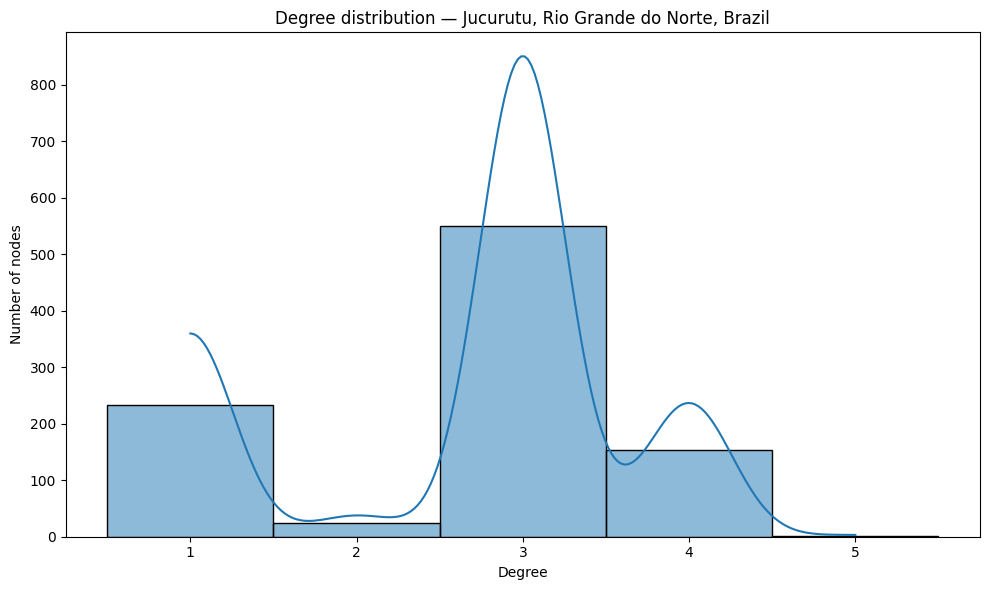

In [ ]:
# Degree distribution: number of nodes per degree value.
# Road networks typically have a very narrow degree range (most intersections
# connect 3 or 4 streets), in contrast to scale-free networks such as the web,
# where a heavy tail of high-degree hubs dominates.

degrees = list(degree_dict.values())

plt.figure(figsize=(10, 6))

sns.histplot(
    degrees,
    binwidth=1,
    binrange=(min(degrees)-0.5, max(degrees)+0.5),
    kde=True
)

plt.xticks(range(min(degrees), max(degrees) + 1))

plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title(f"Degree distribution — {place}")

plt.tight_layout()
plt.show()


In [18]:
# Betweenness centrality: fraction of all-pairs shortest paths that pass
# through each node. High betweenness reveals routing bottlenecks — nodes the
# network depends on to move traffic between distant regions. Cost is roughly
# O(V*E); on a small town graph this runs in seconds.

betweenness = nx.betweenness_centrality(G_simple, normalized=True)

top_btw = sorted(betweenness.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("Top 10 nodes by betweenness centrality:")
for node, val in top_btw:
    print(f"  {node}: {val:.6f}")


Top 10 nodes by betweenness centrality:
  7656057383: 0.463844
  6404307217: 0.403419
  7655540958: 0.392816
  7656057330: 0.390114
  6404307216: 0.386108
  2050161742: 0.383905
  4846323093: 0.372785
  4846323721: 0.367213
  2117186598: 0.350255
  7388615782: 0.348764


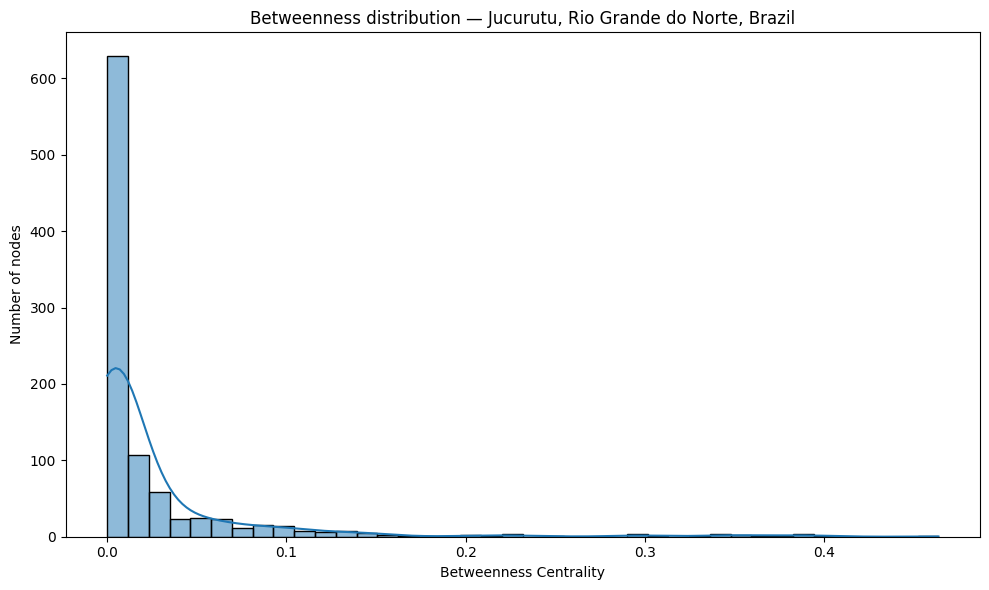

In [29]:
betweenness_values = list(betweenness.values())

plt.figure(figsize=(10, 6))

sns.histplot(
    betweenness_values,
    bins=40,
    kde=True
)

plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of nodes")
plt.title(f"Betweenness distribution — {place}")

plt.tight_layout()
plt.savefig("outputs/betweenness_distribution.png", dpi=150)
plt.show()

In [19]:
# Closeness centrality: inverse of the mean shortest-path distance from the
# node to every other reachable node. High closeness means the node is, on
# average, near every other point of the network.

closeness = nx.closeness_centrality(G_simple)

top_cls = sorted(closeness.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("Top 10 nodes by closeness centrality:")
for node, val in top_cls:
    print(f"  {node}: {val:.6f}")


Top 10 nodes by closeness centrality:
  7655540958: 0.059774
  4846323721: 0.059390
  4846323093: 0.059091
  6404307216: 0.058997
  7388615782: 0.058659
  2050161742: 0.058296
  2117186598: 0.058232
  7654778139: 0.057865
  7656057330: 0.057736
  12182410084: 0.057667


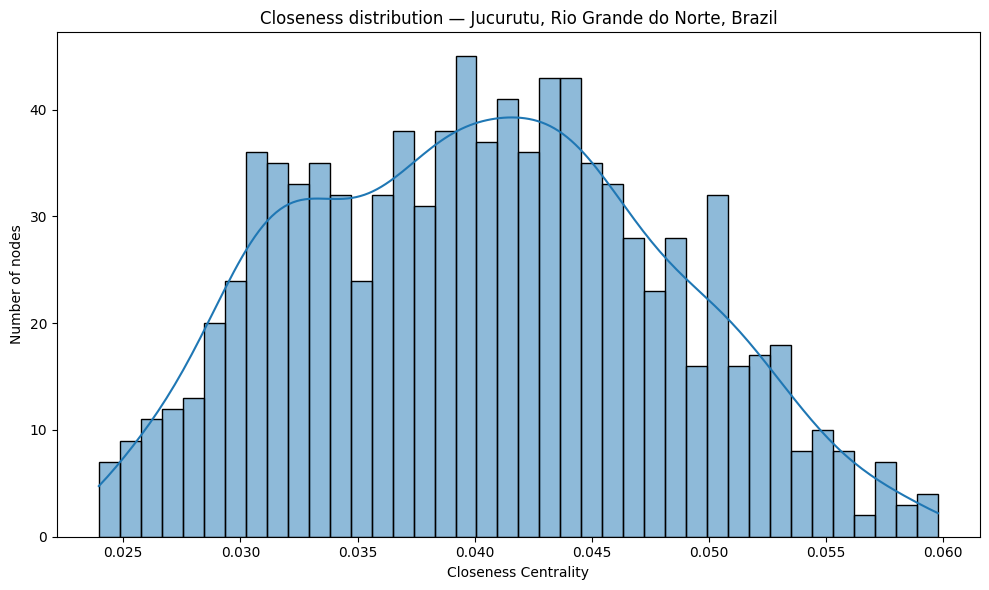

In [31]:
closeness_values = list(closeness.values())

plt.figure(figsize=(10, 6))

sns.histplot(
    closeness_values,
    bins=40,
    kde=True
)

plt.xlabel("Closeness Centrality")
plt.ylabel("Number of nodes")
plt.title(f"Closeness distribution — {place}")

plt.tight_layout()
plt.savefig("outputs/closeness_distribution.png", dpi=150)
plt.show()

Maximum core number (k_max): 2
Core-number distribution:
  k = 1: 287 nodes
  k = 2: 676 nodes

Nodes in the 2-core (main core): 676


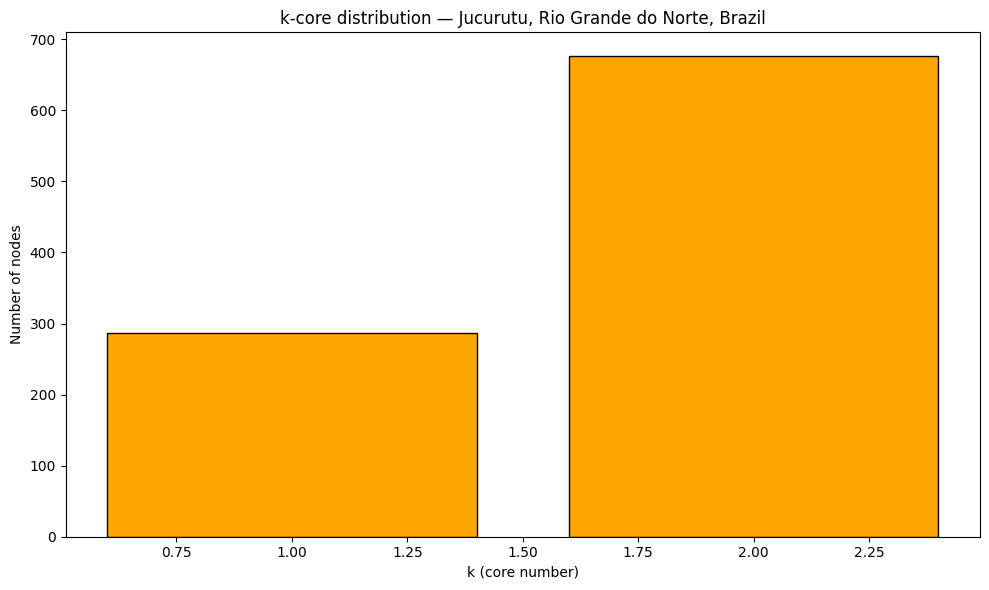

In [35]:
# k-core decomposition: peeling algorithm that iteratively removes nodes with
# degree < k until only nodes belonging to the densest substructure of order k
# remain. The core number of a node is the maximum k such that the node still
# belongs to the k-core. The main core is the subgraph induced by all nodes
# with core number equal to k_max.

core_number = nx.core_number(G_simple)
max_core = max(core_number.values())
print(f"Maximum core number (k_max): {max_core}")

core_counts = Counter(core_number.values())
print("Core-number distribution:")
for k in sorted(core_counts):
    print(f"  k = {k}: {core_counts[k]} nodes")

main_core_nodes = [n for n, c in core_number.items() if c == max_core]
print(f"\nNodes in the {max_core}-core (main core): {len(main_core_nodes)}")

plt.figure(figsize=(10, 6))
plt.bar(core_counts.keys(), core_counts.values(), edgecolor="black", color="orange")
plt.xlabel("k (core number)")
plt.ylabel("Number of nodes")
plt.title(f"k-core distribution — {place}")
plt.tight_layout()
plt.savefig("outputs/core_distribution.png", dpi=150)
plt.show()


### Compiling Network Metrics
Consolidating the calculated metrics into a single DataFrame.

In [21]:
import pandas as pd

network_stats = pd.DataFrame({
    'degree': pd.Series(degree_dict),
    'betweenness': pd.Series(betweenness),
    'closeness': pd.Series(closeness),
    'k_core': pd.Series(core_number)
})

network_stats.head()

,degree,betweenness,closeness,k_core
352698369,1,0.000000,0.035381,1
1834844215,3,0.094338,0.037967,2
2050102272,2,0.000000,0.043277,2
2050103452,4,0.004096,0.045203,2
2050103897,3,0.000042,0.043302,2


### Geographic Mapping
Visualizing the municipality boundaries and the raw street layout.

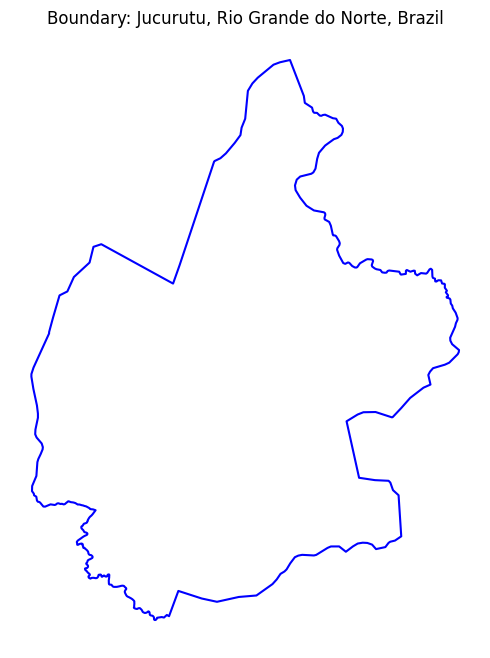

In [22]:
city_boundary = ox.geocode_to_gdf(place)

fig, ax = plt.subplots(figsize=(8, 8))
city_boundary.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=1.5)
plt.title(f"Boundary: {place}")
plt.axis("off")

plt.savefig("outputs/city_limits.png", dpi=300, bbox_inches='tight')
plt.show()

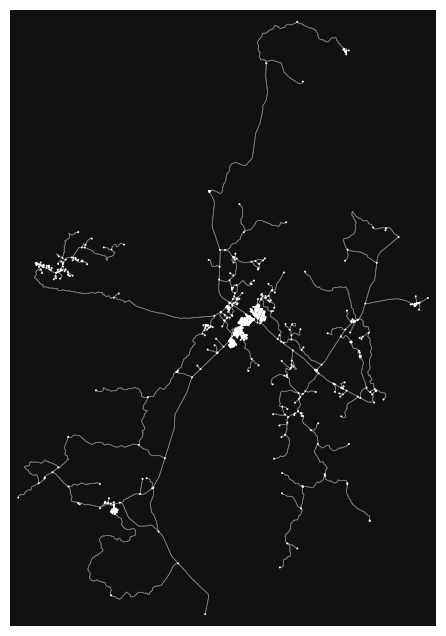

In [23]:
fig, ax = ox.plot_graph(
    G, 
    node_size=2, 
    edge_color="gray", 
    edge_linewidth=0.5,
    show=True, 
    save=True, 
    filepath="outputs/base_network.png", 
    dpi=300
)

### Highlighting Critical Hubs
Plotting the network emphasizing the top 10 nodes with the highest betweenness centrality.

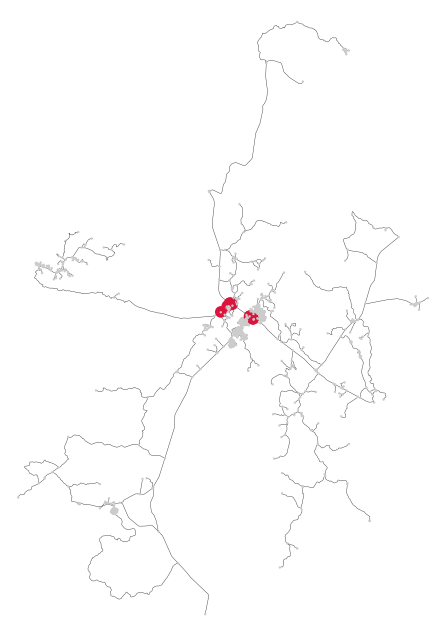

In [24]:
top_bottlenecks = network_stats.nlargest(10, 'betweenness').index

n_colors = ['crimson' if n in top_bottlenecks else '#cccccc' for n in G_undirected.nodes()]
n_sizes = [70 if n in top_bottlenecks else 3 for n in G_undirected.nodes()]

fig, ax = ox.plot_graph(
    G_undirected,
    node_color=n_colors,
    node_size=n_sizes,
    node_zorder=2,
    edge_color="#333333",
    edge_linewidth=0.3,
    bgcolor="white",
    show=True,
    save=True,
    filepath="outputs/critical_hubs.png",
    dpi=300
)

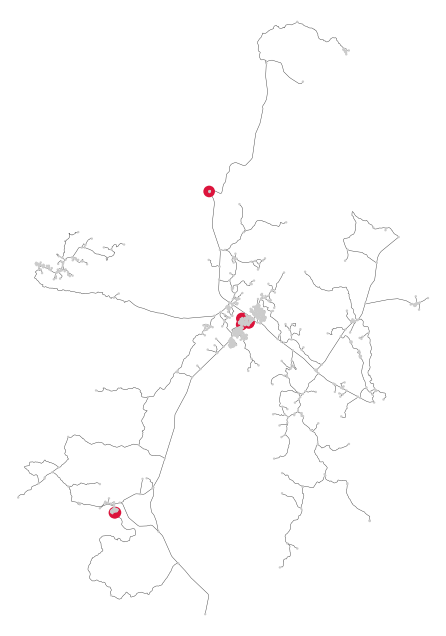

In [28]:
# Top 10 nodes with highest degree
top_degree_nodes = network_stats.nlargest(10, 'degree').index

# Highlight top degree nodes
n_colors = [
    'crimson' if n in top_degree_nodes else '#cccccc'
    for n in G_undirected.nodes()
]

n_sizes = [
    70 if n in top_degree_nodes else 3
    for n in G_undirected.nodes()
]

fig, ax = ox.plot_graph(
    G_undirected,
    node_color=n_colors,
    node_size=n_sizes,
    node_zorder=2,
    edge_color="#333333",
    edge_linewidth=0.3,
    bgcolor="white",
    show=True,
    save=True,
    filepath="outputs/top_degree_nodes.png",
    dpi=300
)

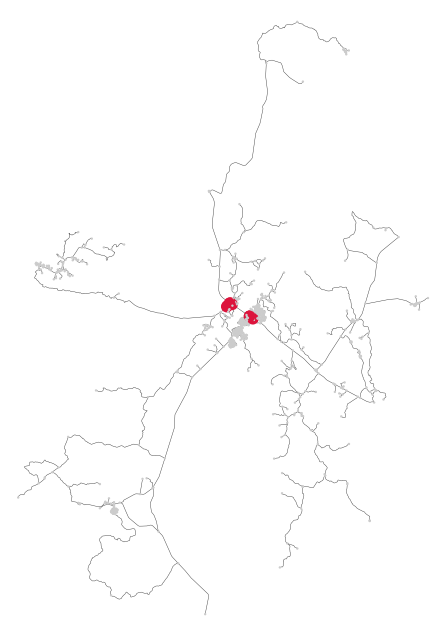

In [33]:
# Add closeness values to the dataframe (if not already present)
network_stats['closeness'] = pd.Series(closeness)

# Top 10 nodes with highest closeness centrality
top_closeness_nodes = network_stats.nlargest(10, 'closeness').index

# Highlight top closeness nodes
n_colors = [
    'crimson' if n in top_closeness_nodes else '#cccccc'
    for n in G_undirected.nodes()
]

n_sizes = [
    70 if n in top_closeness_nodes else 3
    for n in G_undirected.nodes()
]

fig, ax = ox.plot_graph(
    G_undirected,
    node_color=n_colors,
    node_size=n_sizes,
    node_zorder=2,
    edge_color="#333333",
    edge_linewidth=0.3,
    bgcolor="white",
    show=True,
    save=True,
    filepath="outputs/top_closeness_nodes.png",
    dpi=300
)

## Etapa 3 – Exportação do grafo para o Gephi



In [ ]:
# Atribuindo as métricas do network_stats ao G_undirected
nx.set_node_attributes(G_undirected, network_stats['degree'].to_dict(), "degree")
nx.set_node_attributes(G_undirected, network_stats['betweenness'].to_dict(), "betweenness")
nx.set_node_attributes(G_undirected, network_stats['closeness'].to_dict(), "closeness")
nx.set_node_attributes(G_undirected, network_stats['k_core'].to_dict(), "core_number")

# Criando as cópias das coordenadas como números (float) para o plugin Geo Layout
for no, dados in G_undirected.nodes(data=True):
    dados['Latitude'] = float(dados['y'])
    dados['Longitude'] = float(dados['x'])

# Exportando usando a função do OSMnx 
graphml_path = "outputs/rede_urbana.graphml"

#
ox.save_graphml(G_undirected, graphml_path, gephi=True)

print(f"Sucesso! Grafo exportado com {G_undirected.number_of_nodes()} nós e {G_undirected.number_of_edges()} arestas!")


Graph exported to outputs/rede_urbana.graphml
